# H1 클러스터링: 주차 후보 분리 (최적 피처셋)

**목표:** K-Means + DBSCAN으로 주차 후보 클러스터 분리 가능성 검증 (H1)

**피처셋 (feature_selection.ipynb 탐색 결과 — family-diverse 최적):**
`log1p_avg_monthly_delta_cumexp` · `delta_union`(=avg_monthly_delta_union_level, clip≥0) ·
`delta_hfrag`(=avg_monthly_delta_hexa_frag, clip≥0)

> **선정 근거 (feature_selection.ipynb):** 전 피처(22개) 완전탐색 + greedy 결과, naive
> silhouette 1위는 `cumexp_avg/r3/r6`(corr 0.88, 같은 신호 3중복)·`cp+level`(99.7% blob) 등
> **퇴화 조합**이었음. near-constant 제거(dom_frac>0.70) + 비퇴화 게이트(maxfrac≤0.9) +
> 패밀리당 1개 + pairwise|corr|<0.85 적용 → 서로 다른 3개 성장축으로 구성된 이 셋이
> silhouette 0.643 (Set A 5피처 0.473 대비 +0.17)로 최적.
> - cumEXP: level-invariant 성장(주차 후보=0), union: 유니온 성장, hfrag: 헥사 조각 소비(고렙 활성)

**데이터:** `data/features_monthly.csv` → level 270–290 필터 후 ~1,967명
(전처리는 EDA Sec 10 / 기존 H1과 동일하게 재현 — eda.ipynb 수정 없음)


In [1]:
import os, json, warnings
warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
_font_path = "../assets/NanumSquareNeo-bRg.ttf"
font_manager.fontManager.addfont(_font_path)
matplotlib.rcParams["font.family"] = font_manager.FontProperties(fname=_font_path).get_name()
matplotlib.rcParams["axes.unicode_minus"] = False
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 42

def find_elbow_k(ks, inertias):
    # inertia 곡선 양끝 현(chord)까지 수직거리 최대인 k = elbow (양축 [0,1] 정규화)
    x = np.array(ks, dtype=float); y = np.array(inertias, dtype=float)
    x = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y = (y - y.min()) / (y.max() - y.min() + 1e-12)
    x0, y0, x1, y1 = x[0], y[0], x[-1], y[-1]
    num = np.abs((y1 - y0) * x - (x1 - x0) * y + x1 * y0 - y1 * x0)
    den = np.hypot(y1 - y0, x1 - x0) + 1e-12
    return ks[int(np.argmax(num / den))]

# ── 전처리 재현 ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv("../data/features_monthly.csv", encoding="utf-8-sig")
mc = pd.read_csv("../data/main_characters.csv", encoding="utf-8-sig",
                 usecols=["ocid", "class_group"])
df = df_raw.merge(mc, on="ocid", how="left")
hf = pd.read_csv("../data/hexa_fragments.csv", encoding="utf-8-sig",
                 usecols=["ocid", "avg_monthly_delta_hexa_frag"])
df = df.merge(hf, on="ocid", how="left")

df = df[df["level"].between(270, 290)].copy()
df["level_bin"] = pd.cut(df["level"], bins=[269, 279, 285, 290],
                         labels=["270-279", "280-285", "286-290"])

_core = ["avg_monthly_delta_level", "avg_monthly_delta_combat_power",
         "avg_monthly_delta_union_level"]
df = df.dropna(subset=_core).copy()
df.loc[df["avg_monthly_delta_authentic_symbol"] < 0, "avg_monthly_delta_authentic_symbol"] = 0
df["union_level"] = df["union_level"].fillna(0)
df["delta_cp_winsor"] = np.array(
    winsorize(df["avg_monthly_delta_combat_power"].values, limits=[0.05, 0.05]))
df_final = df.reset_index(drop=True)

_stag = ["avg_monthly_delta_level", "delta_cp_winsor",
         "avg_monthly_delta_union_level", "avg_monthly_delta_authentic_symbol"]
df_final["stagnation_score"] = (
    sum((df_final[c] <= df_final[c].quantile(0.25)).astype(int) for c in _stag)
)

# ── 최적 피처셋 (feature_selection.ipynb / optimal_feature_set.json) ──────────
df_final["delta_union"] = df_final["avg_monthly_delta_union_level"].clip(lower=0)
df_final["delta_hfrag"] = df_final["avg_monthly_delta_hexa_frag"].clip(lower=0).fillna(0)
CLUSTER_FEATURES = ["log1p_avg_monthly_delta_cumexp", "delta_union", "delta_hfrag"]

opt = {}
if os.path.exists("optimal_feature_set.json"):
    opt = json.load(open("optimal_feature_set.json", encoding="utf-8"))
FINAL_K = int(opt.get("k", 4))

X_raw  = df_final[CLUSTER_FEATURES].dropna()
idx    = X_raw.index
scaler = StandardScaler()
X      = scaler.fit_transform(X_raw)

# ── 외부 검증 신호 (클러스터링과 독립) ───────────────────────────────────────
park         = (df_final["stagnation_score"] >= 4)            # 강한 주차 후보(다신호)
stag4        = (df_final["stagnation_score"] == 4)
parked_proxy = (df_final["avg_monthly_delta_level"] <= 0.1)

BAND_LABELS  = ["270-279", "280-285", "286-290"]
BAND_PALETTE = {"270-279": "#4e79a7", "280-285": "#f28e2b", "286-290": "#e15759"}

print(f"df_final           : {len(df_final):,}명")
print(f"클러스터링 피처    : {CLUSTER_FEATURES}")
print(f"클러스터링 샘플    : {len(X):,}명  (FINAL_K={FINAL_K})")
print(f"park(stag>=4)      : {park.mean():.1%} (n={int(park.sum())})  |  "
      f"parked_proxy(Δlv<=0.1): {parked_proxy.mean():.1%}")


df_final           : 1,967명
클러스터링 피처    : ['log1p_avg_monthly_delta_cumexp', 'delta_union', 'delta_hfrag']
클러스터링 샘플    : 1,965명  (FINAL_K=4)
park(stag>=4)      : 3.2% (n=63)  |  parked_proxy(Δlv<=0.1): 44.2%


## 피처 진단: 단독 silhouette + leave-one-out

최적셋 3피처 각각의 **단독 클러스터 분리력**과 **leave-one-out 기여도**(제거 시 silhouette 변화)를 확인.
`Δ<0` = 제거 시 악화 = 유지해야 할 피처.


── 단독 피처 silhouette ──


,feature,best_k,silhouette
0,log1p_avg_monthly_delta_cumexp,2,0.8907
1,delta_union,2,0.8874
2,delta_hfrag,2,0.7641



전체 3피처 best silhouette = 0.6430 (k=4)
── leave-one-out (Δ<0 = 유지해야 할 피처) ──


,dropped,silhouette_wo,delta_vs_full
0,delta_union,0.7048,0.0618
1,log1p_avg_monthly_delta_cumexp,0.7416,0.0986
2,delta_hfrag,0.7931,0.1501


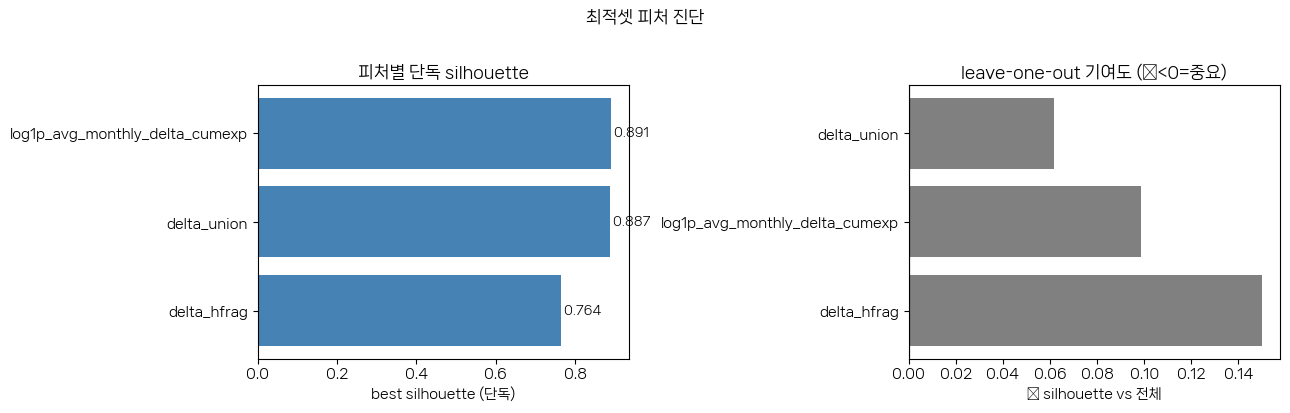

In [2]:
ks_fs = list(range(2, 9))

def best_silhouette(mat):
    sils = [silhouette_score(mat,
                KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(mat))
            for k in ks_fs]
    return max(sils), ks_fs[int(np.argmax(sils))]

# (1) 단독 피처 silhouette
rows = []
for feat in CLUSTER_FEATURES:
    Xf = StandardScaler().fit_transform(df_final.loc[idx, feat].values.reshape(-1, 1))
    sil, bk = best_silhouette(Xf)
    rows.append({"feature": feat, "best_k": bk, "silhouette": sil})
feat_sil = pd.DataFrame(rows).sort_values("silhouette", ascending=False).reset_index(drop=True)
print("── 단독 피처 silhouette ──"); display(feat_sil.round(4))

# (2) leave-one-out
base_sil, base_k = best_silhouette(X)
loo = []
for feat in CLUSTER_FEATURES:
    keep = [c for c in CLUSTER_FEATURES if c != feat]
    Xk = StandardScaler().fit_transform(df_final.loc[idx, keep].values)
    s, _ = best_silhouette(Xk)
    loo.append({"dropped": feat, "silhouette_wo": s, "delta_vs_full": s - base_sil})
loo_df = pd.DataFrame(loo).sort_values("delta_vs_full").reset_index(drop=True)
print(f"\n전체 3피처 best silhouette = {base_sil:.4f} (k={base_k})")
print("── leave-one-out (Δ<0 = 유지해야 할 피처) ──"); display(loo_df.round(4))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4))
fs_r = feat_sil.iloc[::-1]
axL.barh(fs_r["feature"], fs_r["silhouette"], color="steelblue")
axL.set_xlabel("best silhouette (단독)"); axL.set_title("피처별 단독 silhouette")
for i, v in enumerate(fs_r["silhouette"]): axL.text(v, i, f" {v:.3f}", va="center", fontsize=9)
loo_r = loo_df.iloc[::-1]
colors = ["crimson" if d < 0 else "gray" for d in loo_r["delta_vs_full"]]
axR.barh(loo_r["dropped"], loo_r["delta_vs_full"], color=colors)
axR.axvline(0, color="black", linewidth=0.8)
axR.set_xlabel("Δ silhouette vs 전체"); axR.set_title("leave-one-out 기여도 (Δ<0=중요)")
plt.suptitle("최적셋 피처 진단", y=1.02); plt.tight_layout()
plt.savefig("figures/00_feature_silhouette.png", dpi=150, bbox_inches="tight"); plt.show()


## K-Means: Elbow & Silhouette

k=2~8에서 inertia(elbow)와 silhouette를 계산. `FINAL_K`는 feature_selection.ipynb에서 확정한 값(4)을
사용하되, elbow/best-sil k를 함께 표기해 일관성 확인.


elbow k=4  |  best-sil k=4 (0.6430)  |  FINAL_K=4
  k=2: 0.5357
  k=3: 0.5993
  k=4: 0.6430  <-- FINAL_K
  k=5: 0.5786
  k=6: 0.5855
  k=7: 0.5275
  k=8: 0.5188


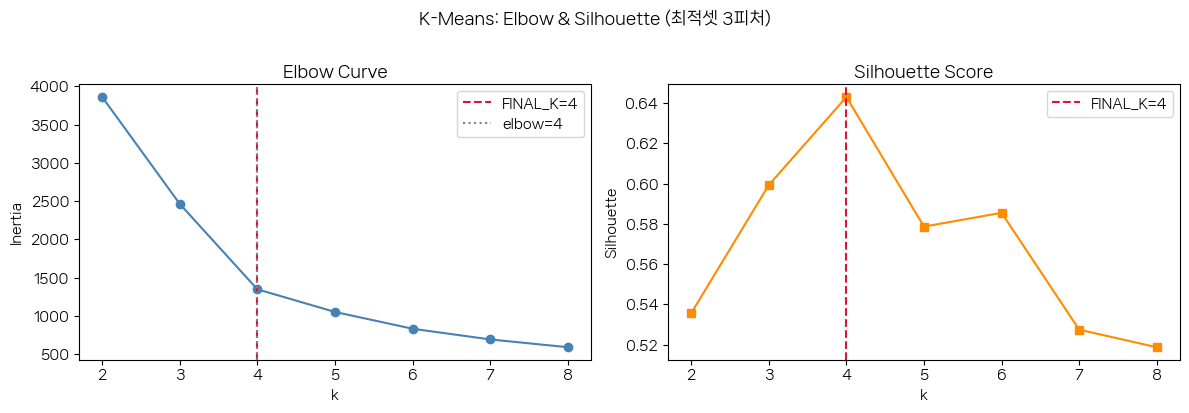

In [3]:
ks = list(range(2, 9))
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X)
    inertias.append(km.inertia_); silhouettes.append(silhouette_score(X, km.labels_))

elbow_k = find_elbow_k(ks, inertias)
bestsil_k = ks[int(np.argmax(silhouettes))]
print(f"elbow k={elbow_k}  |  best-sil k={bestsil_k} ({max(silhouettes):.4f})  |  FINAL_K={FINAL_K}")
for k, s in zip(ks, silhouettes):
    tag = "  <-- FINAL_K" if k == FINAL_K else ""
    print(f"  k={k}: {s:.4f}{tag}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ks, inertias, "o-", color="steelblue")
ax1.axvline(FINAL_K, linestyle="--", color="crimson", label=f"FINAL_K={FINAL_K}")
ax1.axvline(elbow_k, linestyle=":", color="gray", label=f"elbow={elbow_k}")
ax1.set_xlabel("k"); ax1.set_ylabel("Inertia"); ax1.set_title("Elbow Curve")
ax1.set_xticks(ks); ax1.legend()
ax2.plot(ks, silhouettes, "s-", color="darkorange")
ax2.axvline(FINAL_K, linestyle="--", color="crimson", label=f"FINAL_K={FINAL_K}")
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette"); ax2.set_title("Silhouette Score")
ax2.set_xticks(ks); ax2.legend()
plt.suptitle("K-Means: Elbow & Silhouette (최적셋 3피처)", y=1.02); plt.tight_layout()
plt.savefig("figures/01_kmeans_elbow_silhouette.png", dpi=150, bbox_inches="tight"); plt.show()


In [4]:
km_best = KMeans(n_clusters=FINAL_K, n_init=20, random_state=RANDOM_STATE)
df_final.loc[idx, "cluster_km"] = km_best.fit_predict(X)
final_sil = silhouette_score(X, km_best.labels_)

# 성장 정체 클러스터 = cumEXP 성장(=log1p cumexp) 최소 클러스터
g = df_final.loc[idx].groupby("cluster_km")
profile = g[CLUSTER_FEATURES].mean()
profile["n"] = g.size()
profile["park%(stag>=4)"]  = g.apply(lambda x: park.loc[x.index].mean() * 100)
profile["stag4%"]          = g.apply(lambda x: stag4.loc[x.index].mean() * 100)
profile["Δlv≤0.1%"]        = g.apply(lambda x: parked_proxy.loc[x.index].mean() * 100)
stagnant_cluster_id = int(profile["log1p_avg_monthly_delta_cumexp"].idxmin())
profile["is_stagnant_cluster"] = (profile.index == stagnant_cluster_id).astype(int)

print(f"FINAL_K={FINAL_K}  silhouette={final_sil:.4f}  성장 정체 클러스터 ID={stagnant_cluster_id}\n")
display(profile.round(3).T)

print("\n레벨 밴드 분포 (행 비율 %):")
display((pd.crosstab(df_final.loc[idx, "cluster_km"], df_final.loc[idx, "level_bin"],
                     normalize="index") * 100).round(1))
if "class_group" in df_final.columns:
    print("\n계열 분포 (행 비율 %):")
    display((pd.crosstab(df_final.loc[idx, "cluster_km"], df_final.loc[idx, "class_group"],
                         normalize="index") * 100).round(1))


FINAL_K=4  silhouette=0.6430  성장 정체 클러스터 ID=1



cluster_km,0.0,1.0,2.0,3.0
log1p_avg_monthly_delta_cumexp,28.431,0.489,29.538,31.344
delta_union,29.641,4.178,407.103,49.192
delta_hfrag,94.450,35.391,174.844,666.990
n,1271.000,394.000,93.000,207.000
park%(stag>=4),2.203,8.883,0.000,0.000
stag4%,2.203,8.883,0.000,0.000
Δlv≤0.1%,35.877,99.746,12.903,3.865
is_stagnant_cluster,0.000,1.000,0.000,0.000



레벨 밴드 분포 (행 비율 %):


level_bin,270-279,280-285,286-290
cluster_km,,,
0.0,29.7,38.8,31.5
1.0,66.2,31.0,2.8
2.0,25.8,33.3,40.9
3.0,0.0,6.8,93.2



계열 분포 (행 비율 %):


class_group,궁수,도적,마법사,전사,해적
cluster_km,,,,,
0.0,21.9,19.0,21.6,18.0,19.5
1.0,19.0,19.5,18.3,22.6,20.6
2.0,21.5,17.2,17.2,24.7,19.4
3.0,7.7,29.5,15.5,27.1,20.3


## PCA 2D 시각화 (주차 후보 / stagnation / level_bin)

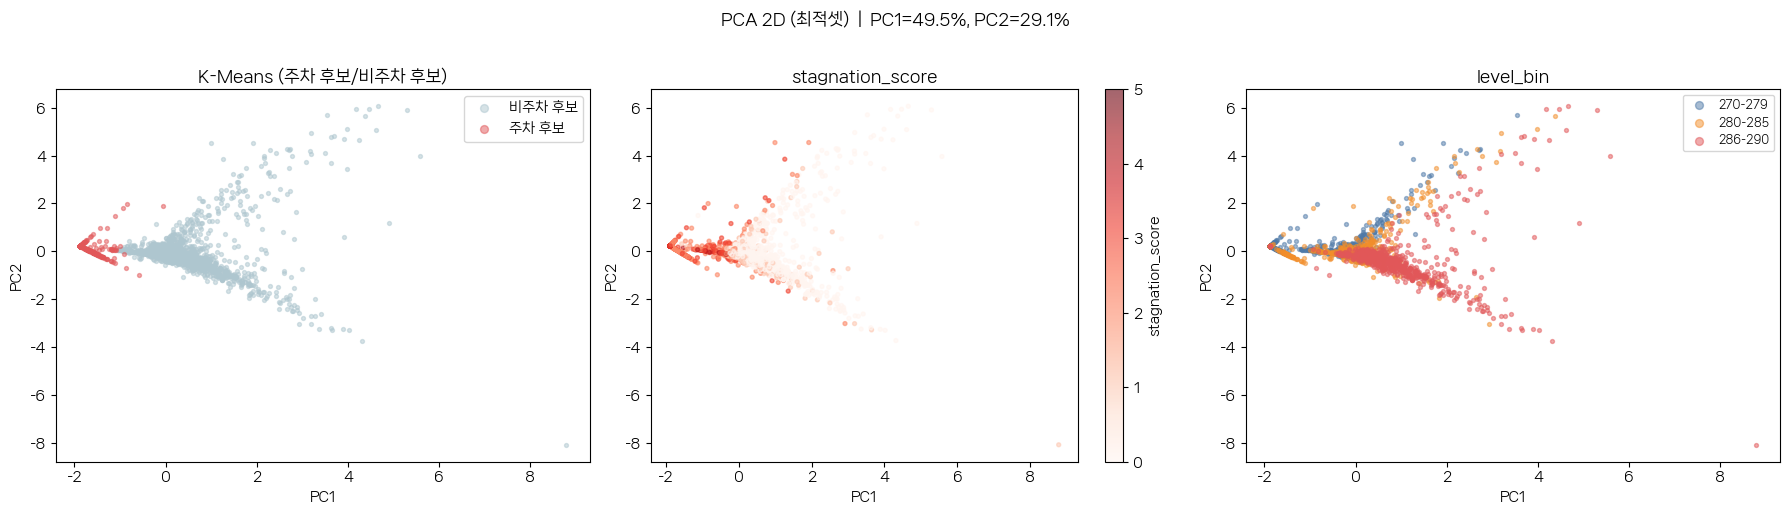

In [5]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=idx).join(
    df_final[["cluster_km", "stagnation_score", "level_bin"]])
pca_df["is_stagnant_cluster"] = (pca_df["cluster_km"] == stagnant_cluster_id).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for cl, (color, lbl) in enumerate(zip(["#aec6cf", "#e15759"], ["비주차 후보", "주차 후보"])):
    m = pca_df["is_stagnant_cluster"] == cl
    axes[0].scatter(pca_df.loc[m, "PC1"], pca_df.loc[m, "PC2"], s=8, alpha=0.5, color=color, label=lbl)
axes[0].set_title("K-Means (주차 후보/비주차 후보)"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=2)

sc = axes[1].scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["stagnation_score"],
                     cmap="Reds", s=8, alpha=0.6, vmin=0, vmax=5)
plt.colorbar(sc, ax=axes[1], label="stagnation_score")
axes[1].set_title("stagnation_score"); axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

for band in BAND_LABELS:
    m = pca_df["level_bin"].astype(str) == band
    if m.sum() > 0:
        axes[2].scatter(pca_df.loc[m, "PC1"], pca_df.loc[m, "PC2"], s=8, alpha=0.5,
                        color=BAND_PALETTE.get(band, "gray"), label=band)
axes[2].set_title("level_bin"); axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")
axes[2].legend(markerscale=2, fontsize=8)

ev = pca.explained_variance_ratio_
plt.suptitle(f"PCA 2D (최적셋)  |  PC1={ev[0]:.1%}, PC2={ev[1]:.1%}", y=1.02); plt.tight_layout()
plt.savefig("figures/02_pca_3panel.png", dpi=150, bbox_inches="tight"); plt.show()


## DBSCAN: 밀도 기반 교차검증

k-distance plot으로 eps 자동 결정(min_samples=2·dim=6) → K-Means 주차 후보 레이블과 교차표로 일관성 확인.


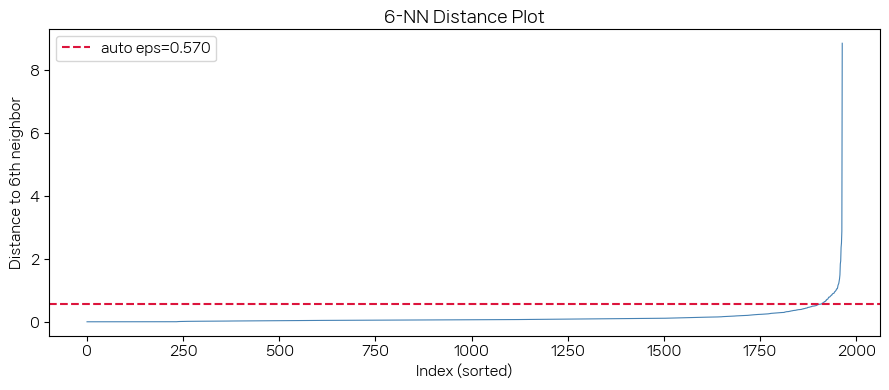

DBSCAN: 1개 클러스터, noise=1.7%, eps=0.5697
    count
-1     33
 0   1932

K-Means(주차 후보) x DBSCAN 교차표:


DBSCAN,-1,0
KM parking=1,,
0,30,1541
1,3,391


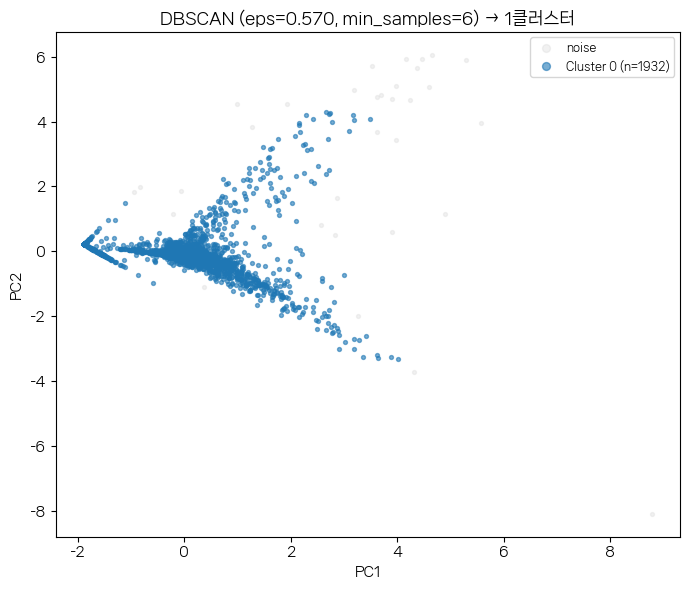

In [6]:
MIN_SAMPLES = 2 * len(CLUSTER_FEATURES)   # = 6
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
dists = np.sort(nbrs.kneighbors(X)[0][:, MIN_SAMPLES - 1])
y_norm = (dists - dists.min()) / (dists.max() - dists.min() + 1e-12)
x_norm = np.linspace(0, 1, len(y_norm))
eps_auto = float(dists[int(np.argmax(np.abs(y_norm - x_norm)))])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dists, color="steelblue", linewidth=0.8)
ax.axhline(eps_auto, linestyle="--", color="crimson", label=f"auto eps={eps_auto:.3f}")
ax.set_title(f"{MIN_SAMPLES}-NN Distance Plot"); ax.set_xlabel("Index (sorted)")
ax.set_ylabel(f"Distance to {MIN_SAMPLES}th neighbor"); ax.legend()
plt.tight_layout()
plt.savefig("figures/03_dbscan_kdist.png", dpi=150, bbox_inches="tight"); plt.show()

db = DBSCAN(eps=eps_auto, min_samples=MIN_SAMPLES).fit(X)
df_final.loc[idx, "cluster_db"] = db.labels_
n_db = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print(f"DBSCAN: {n_db}개 클러스터, noise={ (db.labels_==-1).mean():.1%}, eps={eps_auto:.4f}")
print(pd.Series(db.labels_).value_counts().sort_index().rename("count").to_frame().to_string())

is_stagnant_km = (df_final.loc[idx, "cluster_km"] == stagnant_cluster_id).astype(int)
print("\nK-Means(주차 후보) x DBSCAN 교차표:")
display(pd.crosstab(is_stagnant_km, db.labels_, rownames=["KM parking=1"], colnames=["DBSCAN"]))

# ── DBSCAN PCA 2D 시각화 ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
labs = df_final.loc[idx, "cluster_db"].values
palette = plt.cm.tab10.colors
for lbl in sorted(set(labs)):
    m = labs == lbl
    color = "lightgray" if lbl == -1 else palette[int(lbl) % 10]
    name = "noise" if lbl == -1 else f"Cluster {int(lbl)} (n={int(m.sum())})"
    ax.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.3 if lbl == -1 else 0.6,
               color=color, label=name)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"DBSCAN (eps={eps_auto:.3f}, min_samples={MIN_SAMPLES}) → {n_db}클러스터")
ax.legend(markerscale=2, fontsize=8); plt.tight_layout()
plt.savefig("figures/04_dbscan_clusters.png", dpi=150, bbox_inches="tight"); plt.show()


In [7]:
df_final["is_stagnant_cluster"] = pd.Series(pd.NA, index=df_final.index, dtype="Int64")
df_final.loc[idx, "is_stagnant_cluster"] = (
    df_final.loc[idx, "cluster_km"] == stagnant_cluster_id).astype(int)
df_final.loc[idx, ["ocid", "cluster_km", "is_stagnant_cluster"]].to_csv(
    "../data/cluster_labels.csv", index=False, encoding="utf-8-sig")

n_stagnant = int(df_final["is_stagnant_cluster"].sum())
verdict = "성장 정체 군집 분리 가능" if final_sil > 0.3 else "약한 분리"
# 성장 정체 클러스터의 외부신호 enrich
pk = df_final["is_stagnant_cluster"].fillna(0).eq(1)
enrich = park[pk.values].mean() / max(park.mean(), 1e-9)
recall = park[pk.values].sum() / max(park.sum(), 1)

print("=" * 56)
print("  H1 판정 (최적 피처셋)")
print("=" * 56)
print(f"  피처             : {CLUSTER_FEATURES}")
print(f"  k / Silhouette   : {FINAL_K} / {final_sil:.4f}")
print(f"  판정             : {verdict}")
print(f"  성장 정체 클러스터    : {n_stagnant}명 ({n_stagnant/len(df_final):.1%})")
print(f"  park(stag>=4)    : enrich={enrich:.2f}x, recall={recall:.1%}")
print()
print("  data/cluster_labels.csv 저장 완료")
print("  다음: H2 분포검정 (Chi-Square by level_band & class_group)")


  H1 판정 (최적 피처셋)
  피처             : ['log1p_avg_monthly_delta_cumexp', 'delta_union', 'delta_hfrag']
  k / Silhouette   : 4 / 0.6430
  판정             : 성장 정체 군집 분리 가능
  성장 정체 클러스터    : 394명 (20.0%)
  park(stag>=4)    : enrich=2.77x, recall=55.6%

  data/cluster_labels.csv 저장 완료
  다음: H2 분포검정 (Chi-Square by level_band & class_group)


---
## 결론

- feature_selection.ipynb의 family-diverse 최적셋(`cumEXP·union·hfrag`)으로 K-Means(k=4) 재실행
- 성장 정체 클러스터: cumEXP 성장≈0 + 낮은 union/hfrag + 높은 stagnation·parked_proxy + 저레벨(270–279) 집중
- DBSCAN(eps auto, min_samples=6)은 **단일 군집 + noise 1.7%**만 산출 → 밀도상 성장 정체군집은 본체와 분리되지 않고 **연속 분포**. K-Means 정체군집 394명 중 391명이 같은 DBSCAN 군집에 포함 → 별도 밀도 corroboration 없음(정직한 null). K-Means 분리는 거리 기반 partition 효과로 해석한다.
- `cluster_labels.csv`는 성장 정체 군집 출력이다. H2/H3는 `temporal_external_validation.ipynb`가 생성한 `h1_current_candidates.csv`를 사용한다.

> figure: `00_feature_silhouette` · `01_kmeans_elbow_silhouette` · `02_pca_3panel` ·
> `03_dbscan_kdist` · `04_dbscan_clusters`
